# Continuous Gaussian-means simulations


## Configuration

The default is a
100-draw preview. Change `RUN_FULL` to `True` for the
manuscript's 10,000 draws per setting. Results are written to
`results/`, and figures are written to `results/figures/`.


In [1]:
from pathlib import Path
import sys


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src" / "cp_lfdr").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root containing src/cp_lfdr."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

# Edit DATA_DIR here if the data live outside the repository.
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
SEED = 0
SAVE_FIGURES = True
SAVE_TEX = False
RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    """Save a publication PDF and a high-resolution PNG.

    Set SAVE_FIGURES=False above to disable both. Set SAVE_TEX=True
    to additionally create a PGF-backed .tex file.
    """
    if not SAVE_FIGURES:
        return []
    paths = [
        FIGURE_DIR / f"{stem}.pdf",
        FIGURE_DIR / f"{stem}.png",
    ]
    fig.savefig(paths[0], bbox_inches="tight")
    fig.savefig(paths[1], bbox_inches="tight", dpi=300)
    if SAVE_TEX:
        tex_path = FIGURE_DIR / f"{stem}.tex"
        fig.savefig(tex_path, format="pgf", bbox_inches="tight")
        paths.append(tex_path)
    print(
		"Saved figure:",
		", ".join(str(path.relative_to(PROJECT_ROOT)) for path in paths),
	)
    return paths

import pickle
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cp_lfdr.continuous import run_continuous_setting

RUN_FULL = False
SAVE_RESULTS = True
draws = 10_000 if RUN_FULL else 100


In [2]:
m = 200
sample_size = 10
alpha = 0.1
pi0_values = [0.8, 0.95, 0.99]
tau_values = [0.0, 0.3]
effect_sizes = np.linspace(2, 8, 5)
rng = np.random.default_rng(SEED)

rows = []
all_results = {}
for tau in tau_values:
    all_results[tau] = {}
    for pi0 in pi0_values:
        all_results[tau][pi0] = []
        for xi in effect_sizes:
            result = run_continuous_setting(
                m=m,
                sample_size=sample_size,
                pi0=pi0,
                effect=xi / np.sqrt(sample_size),
                tau=tau,
                alpha=alpha,
                draws=draws,
                rng=rng,
                alpha_grid=np.array([alpha]),
            )
            all_results[tau][pi0].append(result)
            for method, metrics in result["metrics"].items():
                rows.append(
                    {
                        "tau": tau,
                        "pi0": pi0,
                        "effect_size": xi,
                        "method": method,
                        **metrics,
                    }
                )

simulation_results = pd.DataFrame(rows)
simulation_results.head()


,tau,pi0,effect_size,method,bFDR,FDR,Power
0,0.0,0.8,2.0,t-test,0.07,0.094851,0.05000
1,0.0,0.8,2.0,Oracle,0.05,0.041744,0.15400
2,0.0,0.8,2.0,Data-driven,0.04,0.033655,0.11150
3,0.0,0.8,2.0,Weighted,0.08,0.074510,0.07575
4,0.0,0.8,2.0,E-weighted,0.08,0.073990,0.07950


In [3]:
if SAVE_RESULTS:
    result_stem = (
        "continuous_simulations"
        if draws == 10_000
        else f"continuous_simulations_{draws}_draws"
    )
    result_path = RESULTS_DIR / f"{result_stem}.pkl"
    with result_path.open("wb") as handle:
        pickle.dump(all_results, handle)
    summary_path = RESULTS_DIR / f"{result_stem}_summary.csv"
    simulation_results.to_csv(
        summary_path,
        index=False,
    )
    print(f"Saved simulation results: {result_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved simulation summary: {summary_path.relative_to(PROJECT_ROOT)}")


Saved simulation results: results/continuous_simulations_100_draws.pkl
Saved simulation summary: results/continuous_simulations_100_draws_summary.csv


## Observed bFDR and power


In [4]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.2,
})

def plot_by_pi0_for_fixed_diff(
    x_values,
    results_for_diff,
    pi0_values,
    diff,
    x_label,
    alpha,
    p_types=("t-test", "Oracle", "Data-driven", "Weighted", "E-weighted"),
    cp_types=("Oracle", "Data-driven"),
    eps=1e-12,
    save = False,
):
    display_names = {
        "t-test": "t-test",
        "Oracle": "Oracle",
        "Data-driven": "Data-driven",
        "Weighted": "Weighted",
        "E-weighted": "E-weighted",
    }

    p_styles = {
        "t-test": {"color": "tab:red", "marker": "v", "ls": ":"},
        "Oracle": {"color": "tab:green", "marker": "D", "ls": "--"},
        "Data-driven": {"color": "tab:blue", "marker": "o", "ls": "-"},
        "Weighted": {"color": "tab:orange", "marker": "s", "ls": "-."},
        "E-weighted": {"color": "tab:purple", "marker": "P", "ls": "-."},
    }

    gamma_styles = {
        "Oracle": {
            "fixed": {"color": "tab:green", "marker": "D", "ls": "--"},
            "bh": {"color": "tab:olive", "marker": "X", "ls": "-."},
            "minus": {"color": "tab:brown", "marker": "P", "ls": ":"},
        },
        "Data-driven": {
            "fixed": {"color": "tab:blue", "marker": "o", "ls": "-"},
            "bh": {"color": "tab:cyan", "marker": "s", "ls": "-."},
            "minus": {"color": "tab:red", "marker": "v", "ls": ":"},
        },
    }

    n_cols = len(pi0_values)

    fig, axes = plt.subplots(
        2,
        n_cols,
        figsize=(5.8 * n_cols, 11.5),
        sharex=True,
        sharey="row",
        constrained_layout=False,
    )

    if n_cols == 1:
        axes = axes.reshape(2, 1)

    for col, pi_0 in enumerate(pi0_values):
        result = results_for_diff[pi_0]

        history = result["history"]

        # --------------------------------------------------------
        # Row 1: SL bFDR
        # --------------------------------------------------------
        ax = axes[0, col]

        for p_type in p_types:
            key = f"{p_type}_SL_bFDR"

            if key in history:
                ax.plot(
                    x_values,
                    history[key],
                    label=display_names.get(p_type, p_type),
                    color=p_styles[p_type]["color"],
                    marker=p_styles[p_type]["marker"],
                    linestyle=p_styles[p_type]["ls"],
                    linewidth=2.2,
                    markersize=6,
                    markeredgewidth=0.8,
                )

        ax.axhline(
            y=alpha,
            color="black",
            linestyle="-.",
            alpha=0.45,
            linewidth=2,
        )

        ax.set_title(fr"$\pi_0={pi_0}$", fontweight="bold", fontsize=18)

        if col == 0:
            ax.set_ylabel("Observed bFDR", fontsize=15)

        ax.grid(True, which="major", linestyle="--", alpha=0.35)
        ax.tick_params(axis="both", direction="out", length=4, width=0.9)

        # --------------------------------------------------------
        # Row 2: SL Power
        # --------------------------------------------------------
        ax = axes[1, col]

        for p_type in p_types:
            key = f"{p_type}_SL_Power"

            if key in history:
                ax.plot(
                    x_values,
                    history[key],
                    label=display_names.get(p_type, p_type),
                    color=p_styles[p_type]["color"],
                    marker=p_styles[p_type]["marker"],
                    linestyle=p_styles[p_type]["ls"],
                    linewidth=2.2,
                    markersize=6,
                    markeredgewidth=0.8,
                )

        if col == 0:
            ax.set_ylabel("Power", fontsize=15)

        ax.grid(True, which="major", linestyle="--", alpha=0.35)
        ax.tick_params(axis="both", direction="out", length=4, width=0.9)

    # ------------------------------------------------------------
    # Force identical y-limits within each row.
    # sharey="row" usually does this, but this makes it explicit.
    # ------------------------------------------------------------
    for row in range(2):
        ymin = np.inf
        ymax = -np.inf

        for col in range(n_cols):
            lo, hi = axes[row, col].get_ylim()
            ymin = min(ymin, lo)
            ymax = max(ymax, hi)

        pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.01
        ymin = max(0.0, ymin - pad)
        ymax = ymax + pad

        for col in range(n_cols):
            axes[row, col].set_ylim(ymin, ymax)

    # ------------------------------------------------------------
    # Legends
    # ------------------------------------------------------------
    handles1, labels1 = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles1,
        labels1,
        frameon=False,
        loc="lower center",
        ncol=min(len(labels1), 6),
        bbox_to_anchor=(0.5, 0.95),
        title="SL rejection curves",
        fontsize=18,
        title_fontsize=18,
    )

    plt.tight_layout(rect=[0.0, 0.05, 1.0, 0.95])
    if save:
        save_figure(fig, f"t_test_{diff}")

    plt.show()


Saved figure: results/figures/t_test_0.0.pdf, results/figures/t_test_0.0.png


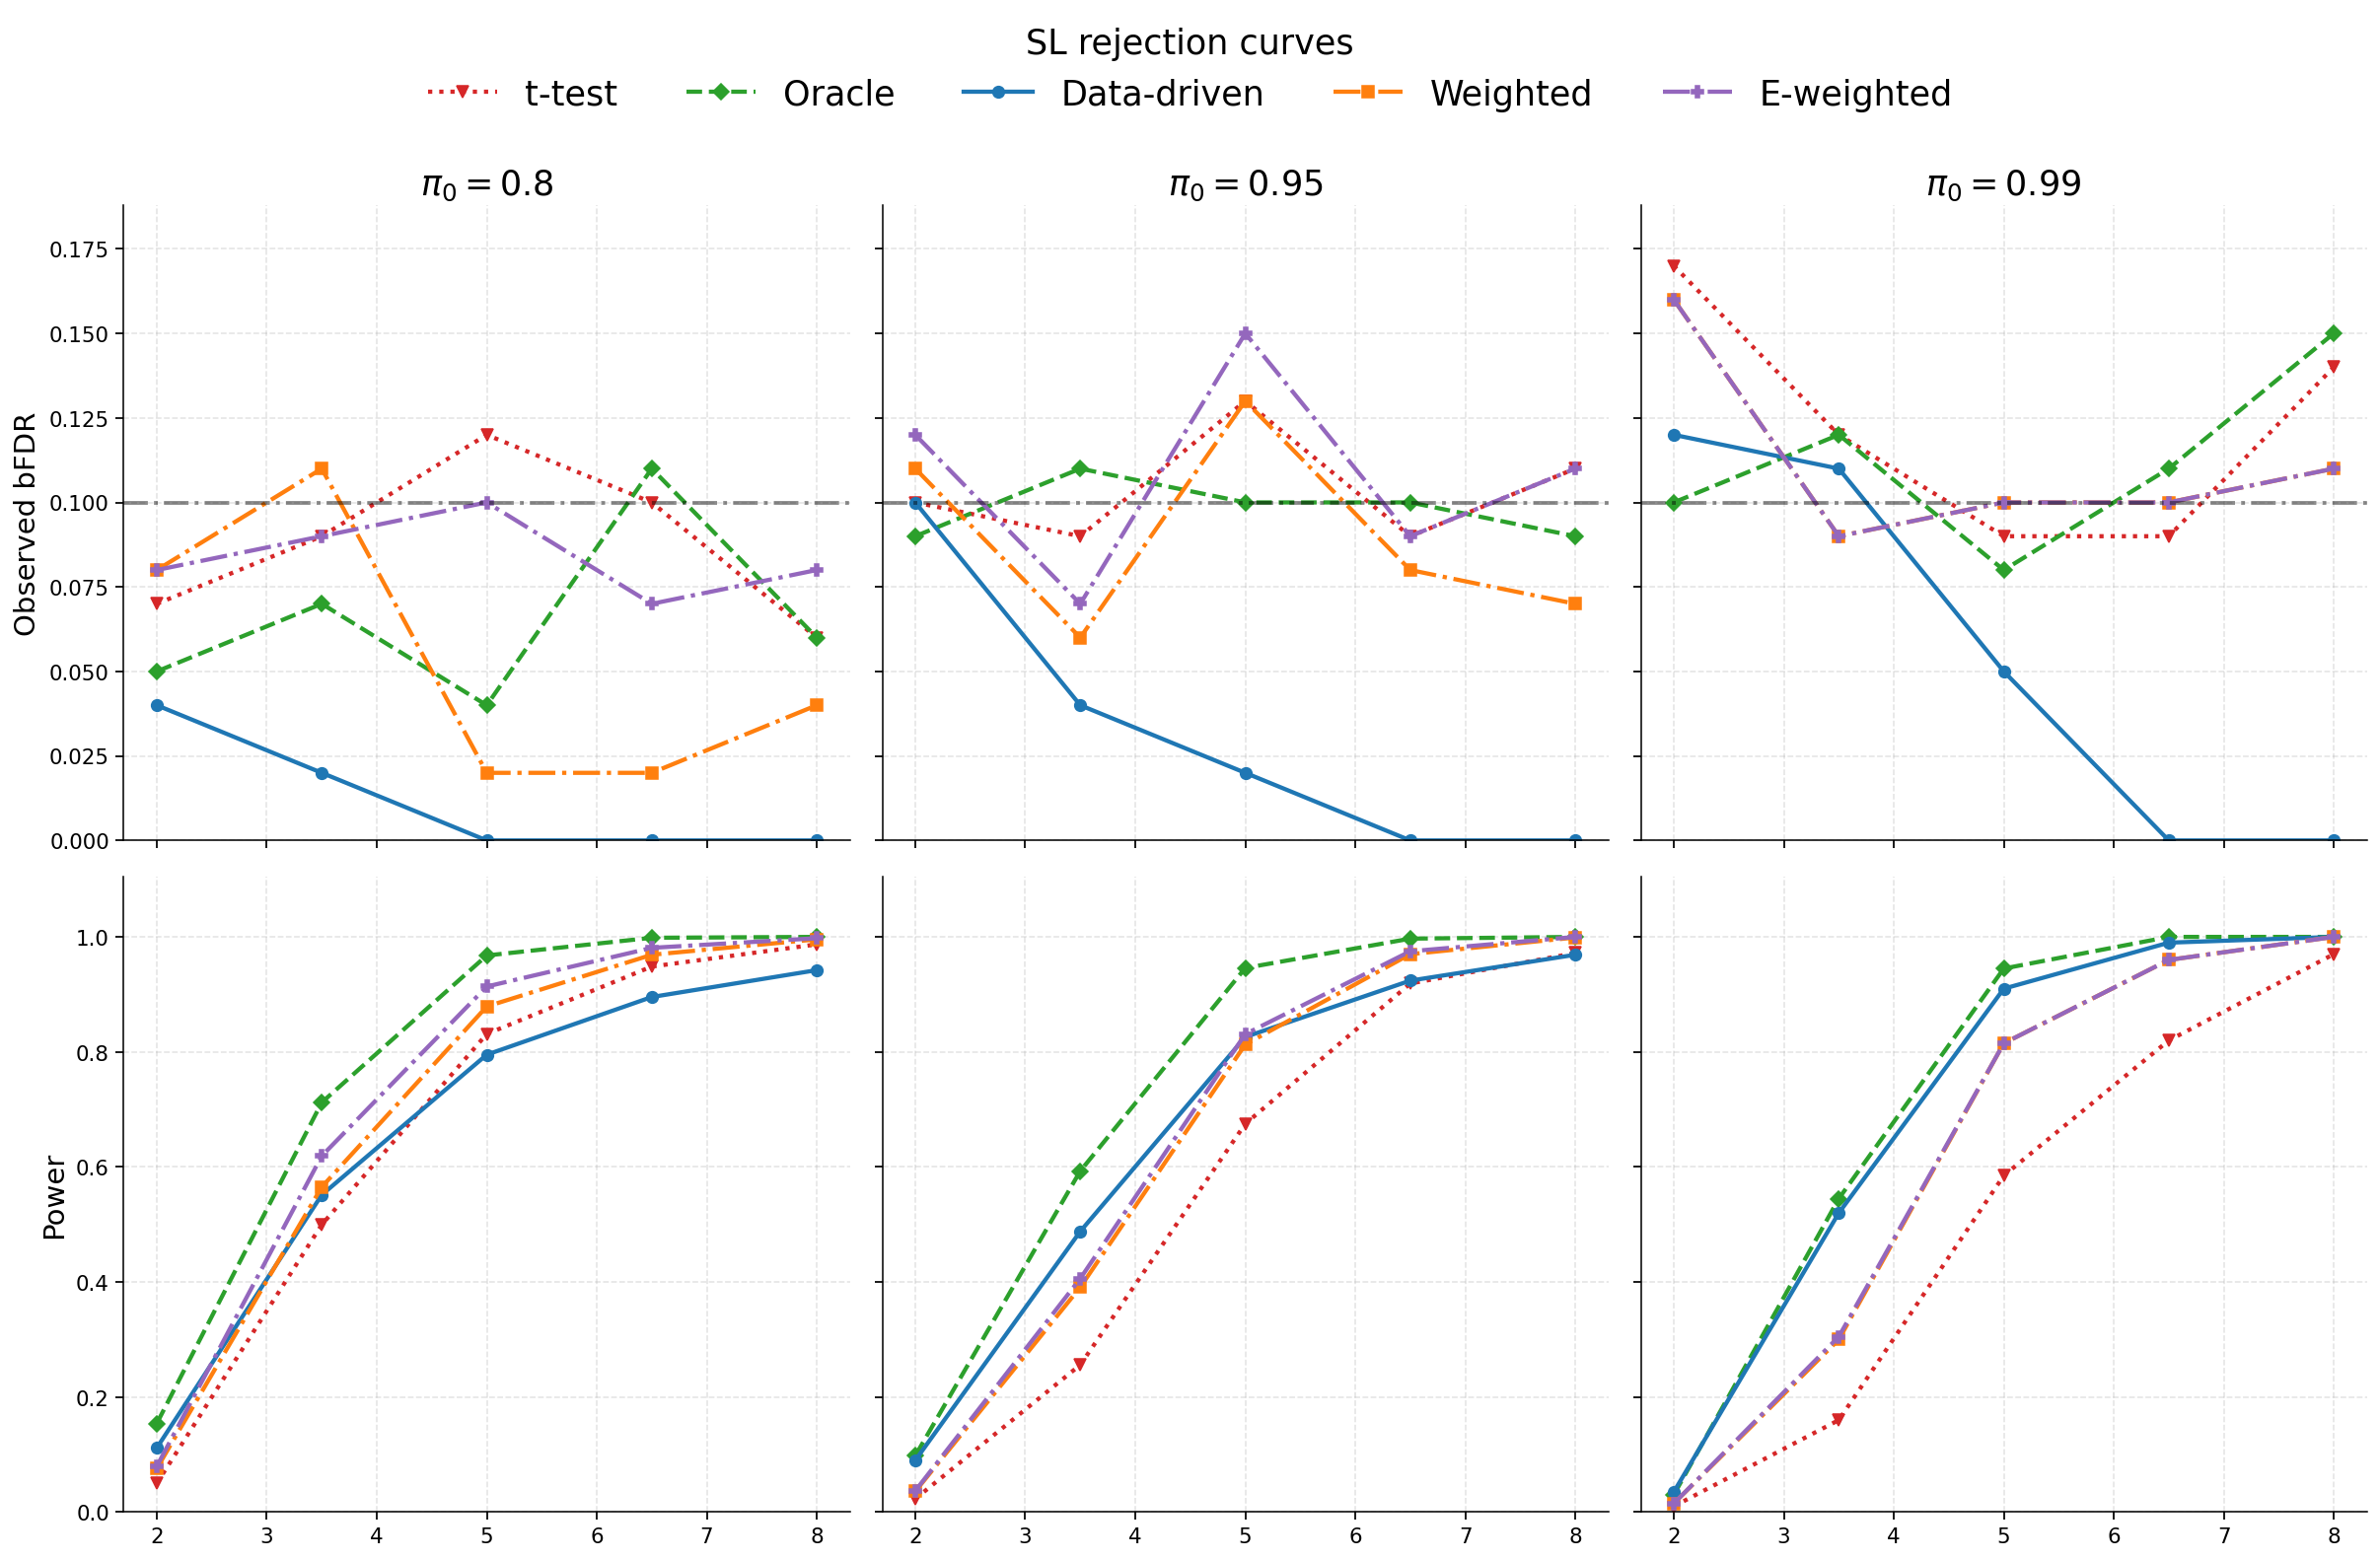

Saved figure: results/figures/t_test_0.3.pdf, results/figures/t_test_0.3.png


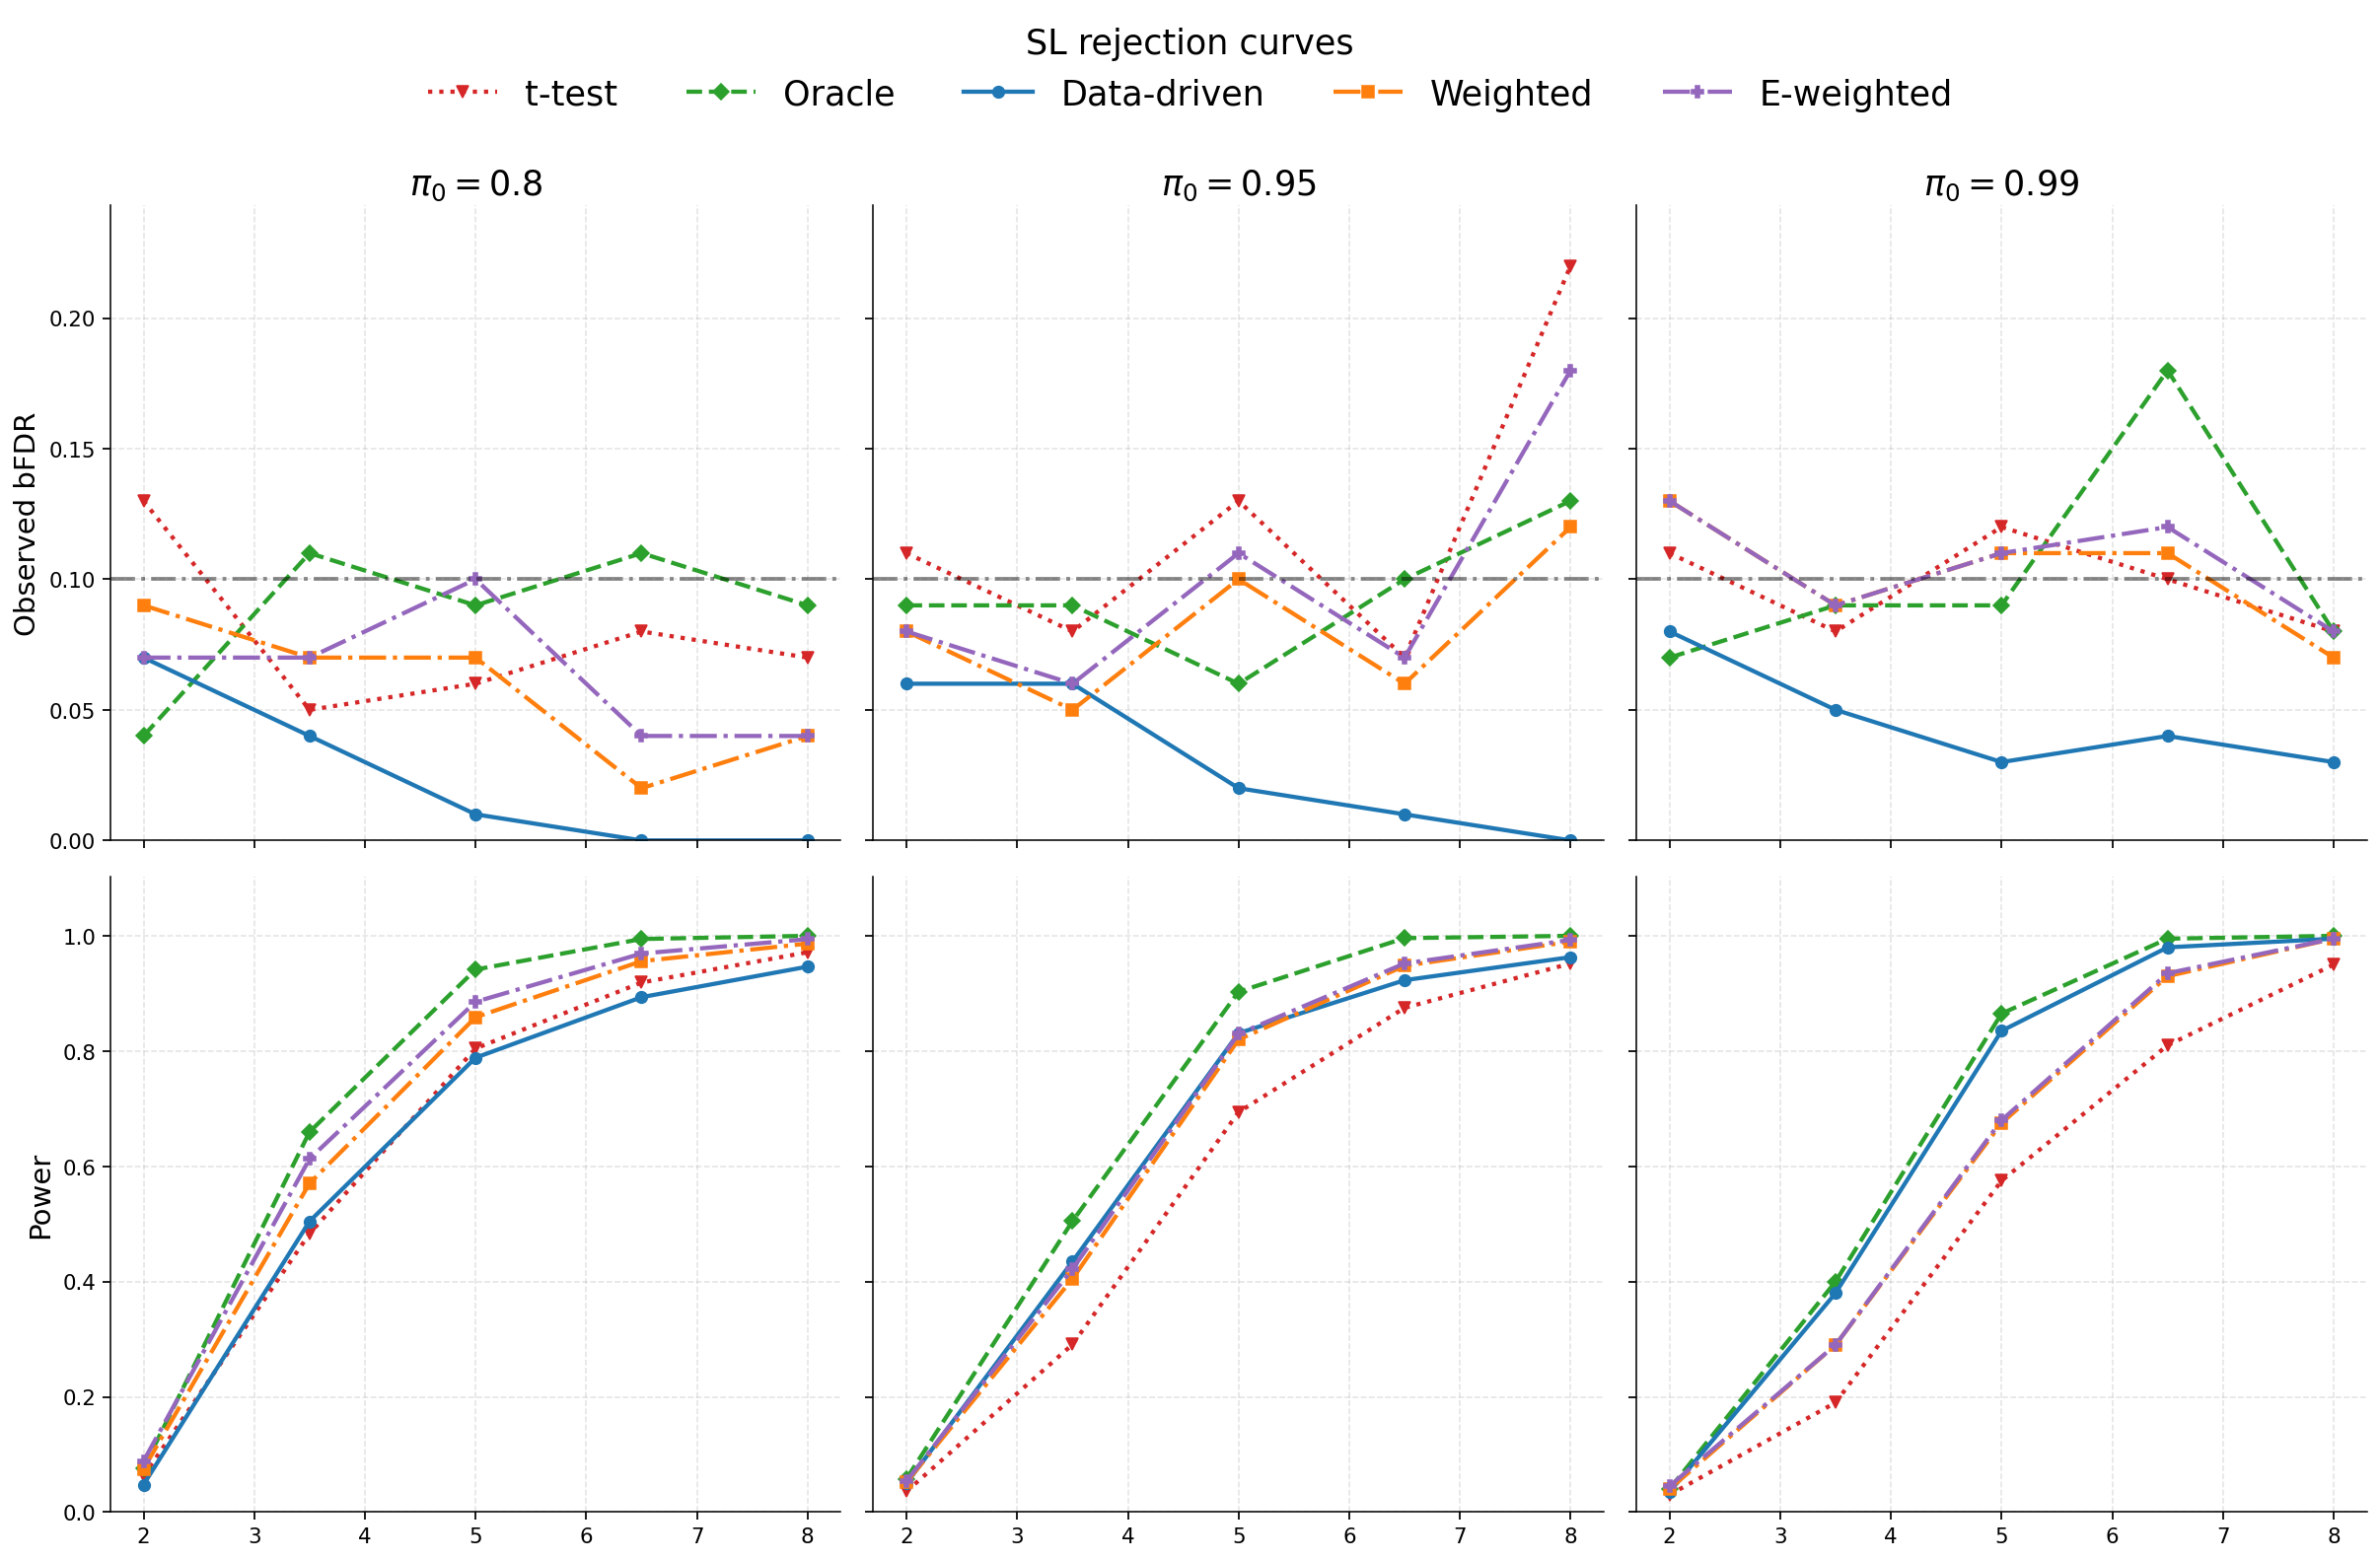

In [5]:
# Convert the simulation result objects to the plotting function's
# expected dictionaries.
plot_results = {}
for tau, tau_results in all_results.items():
    plot_results[tau] = {}
    for pi0, settings in tau_results.items():
        history = defaultdict(list)
        gamma_grid_history = defaultdict(list)
        gamma_minus_history = defaultdict(list)
        gamma_bh_history = defaultdict(list)
        for result in settings:
            for method, method_metrics in result["metrics"].items():
                for metric, value in method_metrics.items():
                    history[f"{method}_SL_{metric}"].append(value)
            for method, levels in result["gamma_grid"].items():
                for level, value in levels.items():
                    gamma_grid_history[
                        f"{method}_alpha={level:.3f}_max_gamma"
                    ].append(value)
            for method, value in result["gamma_minus"].items():
                gamma_minus_history[
                    f"{method}_gamma_minus_max_gamma"
                ].append(value)
            for method, value in result["gamma_bh"].items():
                gamma_bh_history[
                    f"{method}_gamma_bh_max_gamma"
                ].append(value)
        plot_results[tau][pi0] = {
            "history": history,
            "gamma_grid_history": gamma_grid_history,
            "gamma_minus_history": gamma_minus_history,
            "gamma_bh_history": gamma_bh_history,
        }

for tau in tau_values:
    plot_by_pi0_for_fixed_diff(
        x_values=effect_sizes,
        results_for_diff=plot_results[tau],
        pi0_values=pi0_values,
        diff=tau,
        x_label="Effect size",
        alpha=alpha,
        p_types=("t-test", "Oracle", "Data-driven", "Weighted", "E-weighted"),
        cp_types=("Oracle", "Data-driven"),
        save=SAVE_FIGURES,
    )
